In [18]:
# Solver for convergence depending on the mesh 
# 1D let the domain be uniform and defined on [0, 1]
import numpy as np
from scipy.linalg import eigh
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-poster")

In [19]:
# method for putting values on the main diagonal
def off_diag_values_matrix(rank, value):
       # the size should be smaller because there are less numbers off diagonal than on main diagonal
       diag = np.full(rank - 1, value)
       lower_off_centre_diag = np.diag(diag, k=-1)
       higher_off_centre_diag = np.diag(diag, k=1)

       matrix = lower_off_centre_diag + higher_off_centre_diag
       
       return matrix

# stiffness matrix
def stiffness_matrix_A(rank, h):
       # create a matrix (interior_nodes x interior_nodes) of zeros
       A = np.zeros((rank, rank), dtype=float)
       # diagonal values
       a_ii = 2 / h
       np.fill_diagonal(A, a_ii)
       # off diagonal values
       a_ij = -1 / h

       A = A + off_diag_values_matrix(rank, a_ij)
       return A

# mass matrix
def mass_matrix_M(rank, h):
       # create a matrix (interior_nodes x interior_nodes) of zeros
       M = np.zeros((rank, rank), dtype=float)
       # diagonal values
       m_ii = (4 * h) / 6
       np.fill_diagonal(M, m_ii)
       # off diagonal values
       m_ij = h / 6

       M = M + off_diag_values_matrix(rank, m_ij)
       return M

# error of all eigenvalues
# takes 2 lists of real eigenvalues and computed
def all_eigval_error(real_eigvals: list, comp_eigvals: list):
       # for values in both arrays
       for real_val, val in zip(real_eigvals, comp_eigvals):
              error = abs(real_val - val)
              print(
                     f"Computed eigenvalue: {val:.5f}\n",
                     f"Real value: {real_val:.5f}\n",
                     f"Error: {error:.5f}"
              )

# error of the first eigenvalue
# will get only the first elements of the arrays
def first_eigval_error(real_eigval, comp_eigval):
       error = abs(real_eigval - comp_eigval)
       return error


# update table
def add_row_to_table(table, row):
       table.loc[len(table)] = row

       return table
       

def plotting_convergence(h_vals: list, errors: list, p):
       fig, ax = plt.subplots(figsize=(10, 8))
       ax.plot(np.log2(h_vals), np.log2(errors), marker="o")
       ax.set_xlabel(r"$\log_2 h$")
       ax.set_ylabel(r"$\log_2 (E(h)) = \log_2(|\lambda_1 - \lambda_1^h|)$")
       ax.set_title("Convergence of the FEM eigenvalues")
       ax.legend(title=f"The slope of this graph (global convergence rate) is {p:.5f}")
       ax.grid(True)



Global convergence rate is 2.01400
      N         h   lambda_1  lambda_real     error  convergence rate
1   2.0  0.500000  12.000000     9.869604  2.130396          0.000000
2   4.0  0.250000  10.386642     9.869604  0.517038          2.042780
3   8.0  0.125000   9.997081     9.869604  0.127476          2.020041
4  16.0  0.062500   9.901354     9.869604  0.031749          2.005433
5  32.0  0.031250   9.877534     9.869604  0.007930          2.001383
6  64.0  0.015625   9.871586     9.869604  0.001982          2.000347


/var/folders/tm/0p84bx055552mh0gmxrfqdx00000gn/T/ipykernel_6908/4270493271.py:70: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title=f"The slope of this graph (global convergence rate) is {p:.5f}")


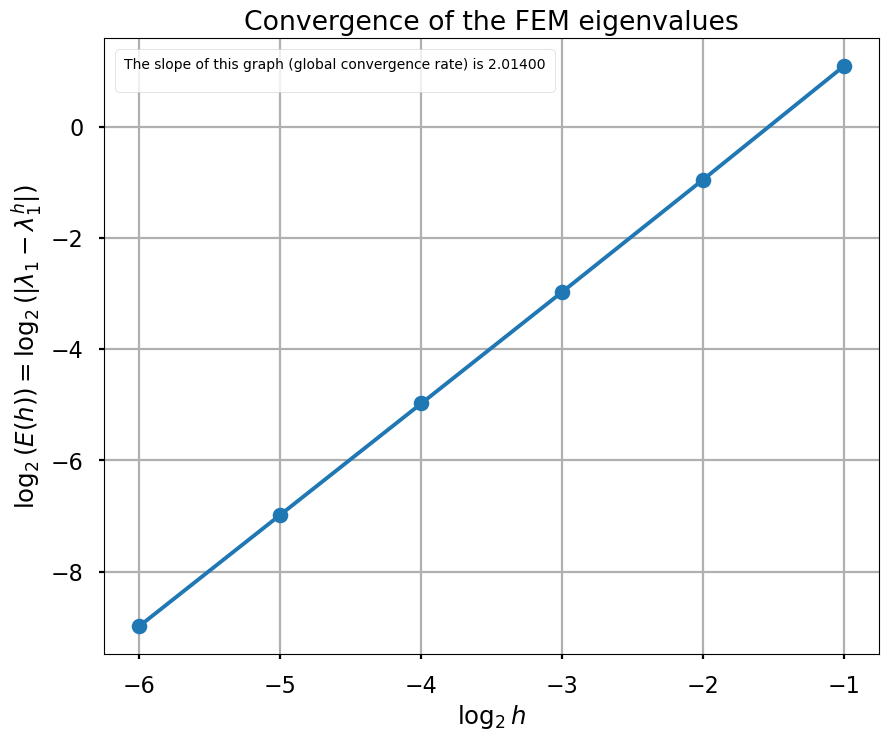

In [ ]:
def convergence_study(list_of_meshes: list):

       # create an empty table
       table = pd.DataFrame(columns=["N", "h", "lambda_1", "lambda_real", "error", "convergence rate"])

       errors = []
       p_local = []
       h_vals = []

       for i in range(len(list_of_meshes)):
              num_elements = list_of_meshes[i]

              row_i = []
              row_i.append(num_elements)
              # find the step
              h = 1 / num_elements
              row_i.append(h)
              h_vals.append(h)
              # get the interior nodes
              interior_nodes = num_elements - 1

              # stiffness matrix
              A = stiffness_matrix_A(interior_nodes, h)
              M = mass_matrix_M(interior_nodes, h)
              # get the eigenvalues and eigenvectors
              # it will give 2 arrays, one for eigenvalues, another for eigenvectors
              eigvals, eigvecs = eigh(A, M)
              row_i.append(float(eigvals[0]))

              # real eigenvalue
              real_eigval = (np.pi)**2
              row_i.append(float(real_eigval))

              # first eigenvalue error
              error = first_eigval_error(real_eigval, eigvals[0])
              errors.append(error)
              row_i.append(float(error))


              # convergence rate
              # local convergence rate log2(e_i/e_i+1) 
              if i == 0:
                     row_i.append(0)
              else:
                     # finds the ratio of the previous error and current error
                     p_i = np.log2(errors[i-1] / errors[i])
                     row_i.append(p_i)
                     p_local.append(p_i)
              
              add_row_to_table(table, row_i)

       # global convergence rate
       p = np.mean(np.array(p_local))
       print(f"Global convergence rate is {p:.5f}\n")

       # make indexes from 1
       table.index = np.arange(1, len(table) + 1)
       print(table)

       # plot the convergence
       plotting_convergence(h_vals, errors, p)
       plt.show()
       
convergence_study([2, 4, 8, 16, 32, 64])